In [7]:
# %% Setup
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoid libomp double-init abort (numpy and torch both bundle OpenMP on macOS)
os.environ.setdefault("OMP_NUM_THREADS", "1")           # avoids an OMP pthread_mutex_init segfault during inference on macOS

from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import torch
from chronos import Chronos2Pipeline

USE_FINETUNED = True   # True = LoRA fine-tuned weights (local folder, else HF Hub); False = default amazon/chronos-2

BASE_MODEL = "amazon/chronos-2"
LOCAL_CKPT = "chronos-2-finetuned-final"          # written by Chronos2-FineTune.ipynb
HF_REPO_ID = "Imker0311/chronos-2-cstr-lora"      # private Hub copy, pushed by Chronos2-FineTune.ipynb


def resolve_checkpoint(finetuned):
    """Base model, or the fine-tuned checkpoint - local if present, else pulled from the Hub."""
    if not finetuned:
        return BASE_MODEL
    if Path(LOCAL_CKPT).is_dir():
        return LOCAL_CKPT
    from huggingface_hub import snapshot_download
    from huggingface_hub.errors import HfHubHTTPError
    try:
        return snapshot_download(repo_id=HF_REPO_ID, repo_type="model")
    except HfHubHTTPError as exc:
        raise FileNotFoundError(
            f"Could not download '{HF_REPO_ID}' from the Hugging Face Hub: {exc}\n"
            f"If the repo is private, authenticate first: `hf auth login` (or set HF_TOKEN)."
        ) from exc


device = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = resolve_checkpoint(USE_FINETUNED)
kwargs = dict(device_map=device)
if USE_FINETUNED:
    # LoRA adapter: needs peft, and peft's AutoPeftModel must be allowed to import the Chronos-2 model class.
    kwargs["import_allowlist"] = ["chronos.chronos2.model"]
pipeline = Chronos2Pipeline.from_pretrained(CHECKPOINT, **kwargs)

MODEL_LABEL = "Chronos-2 fine-tuned" if USE_FINETUNED else "Chronos-2"
print(f"Loaded {MODEL_LABEL} from {CHECKPOINT} on {device}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loaded Chronos-2 fine-tuned from /Users/imkerhoogenhout/.cache/huggingface/hub/models--Imker0311--chronos-2-cstr-lora/snapshots/03dfd79ee95dfe58468a1f2da3ee111bac50a542 on cpu


In [8]:
# %% Load and align data: states (targets) + exogenous inputs (covariates)
STATE_COLUMNS = {"C_A": "C_A", "T": "T", "T_C": "T_C", "h": "h", "Q_vec": "Q", "Q_c_vec": "Qc"}
EXOG_COLUMNS = {"F1": "E_R", "F2": "U_Ac", "F4": "T_F", "F5": "C_F", "F6": "T_CF", "F7": "Q_F"}

DOWNSAMPLE = 20  # must match FACTOR in CSTR-Downsample.ipynb

with h5py.File(f"CSTR_SimulationData_ds{DOWNSAMPLE}.h5", "r") as f:
    data = {col: f[key][:, 0] for key, col in STATE_COLUMNS.items()}
    n = len(data["C_A"])
    print(n, "samples loaded from CSTR_SimulationData_ds{DOWNSAMPLE}.h5")

# state[j] corresponds to raw input index 1 + j, strided by DOWNSAMPLE to match the full-resolution input file
idx = 1 + np.arange(n) * DOWNSAMPLE

with h5py.File("CSTR_InputVectors.h5", "r") as f:
    for key, col in EXOG_COLUMNS.items():
        data[col] = f[key][idx, 0]
    flags = {key: f[f"{key}.plt"][idx] for key in EXOG_COLUMNS}

df = pd.DataFrame(data)
df["item_id"] = "cstr"
df["timestamp"] = pd.date_range("2026-01-01", periods=n, freq=f"{DOWNSAMPLE}s")
df = df[["item_id", "timestamp"] + list(STATE_COLUMNS.values()) + list(EXOG_COLUMNS.values())]
df.head()

5000 samples loaded from CSTR_SimulationData_ds{DOWNSAMPLE}.h5


,item_id,timestamp,C_A,T,T_C,h,Q,Qc,E_R,U_Ac,T_F,C_F,T_CF,Q_F
0,cstr,2026-01-01 00:00:00,0.042680,402.235112,345.203306,0.600000,1.666657,0.249995,8750.0,833.333333,319.974511,0.999984,300.000496,1.666687
1,cstr,2026-01-01 00:00:20,0.036173,402.747833,344.968421,0.600167,1.666310,0.263921,8750.0,833.333333,319.934461,0.999772,300.017229,1.666107
2,cstr,2026-01-01 00:00:40,0.038006,401.882899,344.616651,0.600123,1.665862,0.256489,8750.0,833.333333,319.869430,0.999928,300.021288,1.665757
3,cstr,2026-01-01 00:01:00,0.038446,401.731625,344.730512,0.600103,1.666388,0.252465,8750.0,833.333333,319.971990,1.000179,300.026596,1.665872
4,cstr,2026-01-01 00:01:20,0.038290,401.815817,344.853108,0.600071,1.665903,0.252479,8750.0,833.333333,320.045624,0.999929,300.002199,1.665687


In [14]:
# %% Simulation settings
INIT_CONTEXT = 3500    # samples of actual data used to initialise the model - everything after this is model output
N_STEPS = 512         # number of steps to simulate after INIT_CONTEXT; None = run to the end of the data (slow on CPU)
MAX_CONTEXT = None    # cap on the context window the model sees each step (older samples dropped); None = model max. Smaller = faster
PREDICTION_LENGTH = 64   # steps predicted per model call before they are appended to the context; 1 = one step at a time (unstable)

PAST_ONLY = []        # exogenous inputs given in the context but NOT for the steps being predicted
NO_PAST = []          # exogenous inputs NOT given in the context (hidden as NaN) but given for the steps being predicted
# an input in both lists is removed from the model entirely

END = n if N_STEPS is None else min(INIT_CONTEXT + N_STEPS, n)
MAX_CONTEXT = MAX_CONTEXT or pipeline.model_context_length
assert PREDICTION_LENGTH >= 1, "PREDICTION_LENGTH must be at least 1"
PAST_EXOG = [c for c in EXOG_COLUMNS.values() if not (c in PAST_ONLY and c in NO_PAST)]
FUTURE_EXOG = [c for c in PAST_EXOG if c not in PAST_ONLY]   # Chronos-2 requires future covariates to also be past covariates

print(
    f"Simulating samples {INIT_CONTEXT} to {END} ({END - INIT_CONTEXT} steps) from {INIT_CONTEXT} samples of initial context, "
    f"context capped at {MAX_CONTEXT}\n{PREDICTION_LENGTH} steps per model call "
    f"({-(-(END - INIT_CONTEXT) // PREDICTION_LENGTH)} calls)\npast covariates: {PAST_EXOG}\nfuture covariates: {FUTURE_EXOG}"
)

Simulating samples 3500 to 4012 (512 steps) from 3500 samples of initial context, context capped at 8192
64 steps per model call (8 calls)
past covariates: ['E_R', 'U_Ac', 'T_F', 'C_F', 'T_CF', 'Q_F']
future covariates: ['E_R', 'U_Ac', 'T_F', 'C_F', 'T_CF', 'Q_F']


In [15]:
# %% Run Chronos-2 as a dynamic model: predict PREDICTION_LENGTH steps, append them to the context, repeat
from tqdm.auto import tqdm

QUANTILES = [0.1, 0.5, 0.9]
state_cols = list(STATE_COLUMNS.values())

sim = df[state_cols].to_numpy().T.copy()          # (n_states, n); actual data up to INIT_CONTEXT, overwritten with model output after
lo, hi = np.full_like(sim, np.nan), np.full_like(sim, np.nan)
exog = {c: df[c].to_numpy() for c in PAST_EXOG}
exog_past = {c: np.full(n, np.nan) if c in NO_PAST else exog[c] for c in PAST_EXOG}

for t in tqdm(range(INIT_CONTEXT, END, PREDICTION_LENGTH)):
    h = min(PREDICTION_LENGTH, END - t)           # last chunk is shortened so the run stops exactly at END
    start = max(t - MAX_CONTEXT, 0)
    inputs = [{
        "target": sim[:, start:t],
        "past_covariates": {c: exog_past[c][start:t] for c in PAST_EXOG},
        "future_covariates": {c: exog[c][t:t + h] for c in FUTURE_EXOG},
    }]
    quantiles, _ = pipeline.predict_quantiles(inputs, prediction_length=h, quantile_levels=QUANTILES)
    q = quantiles[0].cpu().numpy()                # (n_states, h, n_quantiles)
    lo[:, t:t + h], sim[:, t:t + h], hi[:, t:t + h] = q[..., 0], q[..., 1], q[..., 2]   # medians become the next chunk's context

# model outputs only (INIT_CONTEXT onwards), alongside the actual simulation
sim_df = df.iloc[INIT_CONTEXT:END][["item_id", "timestamp"]].copy()
for i, col in enumerate(state_cols):
    sim_df[col] = sim[i, INIT_CONTEXT:END]
    sim_df[f"{col}_0.1"] = lo[i, INIT_CONTEXT:END]
    sim_df[f"{col}_0.9"] = hi[i, INIT_CONTEXT:END]
truth_df = df.iloc[INIT_CONTEXT:END].copy()
sim_df.head()

  0%|          | 0/8 [00:00<?, ?it/s]

,item_id,timestamp,C_A,C_A_0.1,C_A_0.9,T,T_0.1,T_0.9,T_C,T_C_0.1,T_C_0.9,h,h_0.1,h_0.9,Q,Q_0.1,Q_0.9,Qc,Qc_0.1,Qc_0.9
3500,cstr,2026-01-01 19:26:40,0.075486,0.073966,0.077548,401.624939,401.500946,401.735779,347.580963,347.415741,347.812561,0.600001,0.599990,0.600016,1.667364,1.665561,1.668323,0.223675,0.220761,0.225933
3501,cstr,2026-01-01 19:27:00,0.075493,0.073867,0.077373,401.659515,401.548126,401.780090,347.594666,347.402893,347.766754,0.600003,0.599988,0.600016,1.666525,1.665368,1.669014,0.223918,0.221073,0.226358
3502,cstr,2026-01-01 19:27:20,0.075566,0.073894,0.077295,401.660645,401.539001,401.792816,347.548584,347.382599,347.730133,0.600001,0.599988,0.600015,1.666521,1.665498,1.668686,0.223870,0.220770,0.226210
3503,cstr,2026-01-01 19:27:40,0.075245,0.073890,0.077397,401.689056,401.557281,401.823822,347.532043,347.345490,347.734497,0.600001,0.599986,0.600016,1.666680,1.664991,1.668363,0.224085,0.221448,0.226412
3504,cstr,2026-01-01 19:28:00,0.075426,0.073895,0.077206,401.723755,401.585297,401.875885,347.607239,347.442322,347.842957,0.600002,0.599988,0.600017,1.667342,1.665744,1.668512,0.224430,0.221778,0.226986


C_A: MAE = 0.00081941
T: MAE = 0.05615
T_C: MAE = 0.11987
h: MAE = 1.5189e-05
Q: MAE = 0.002083
Qc: MAE = 0.00076432


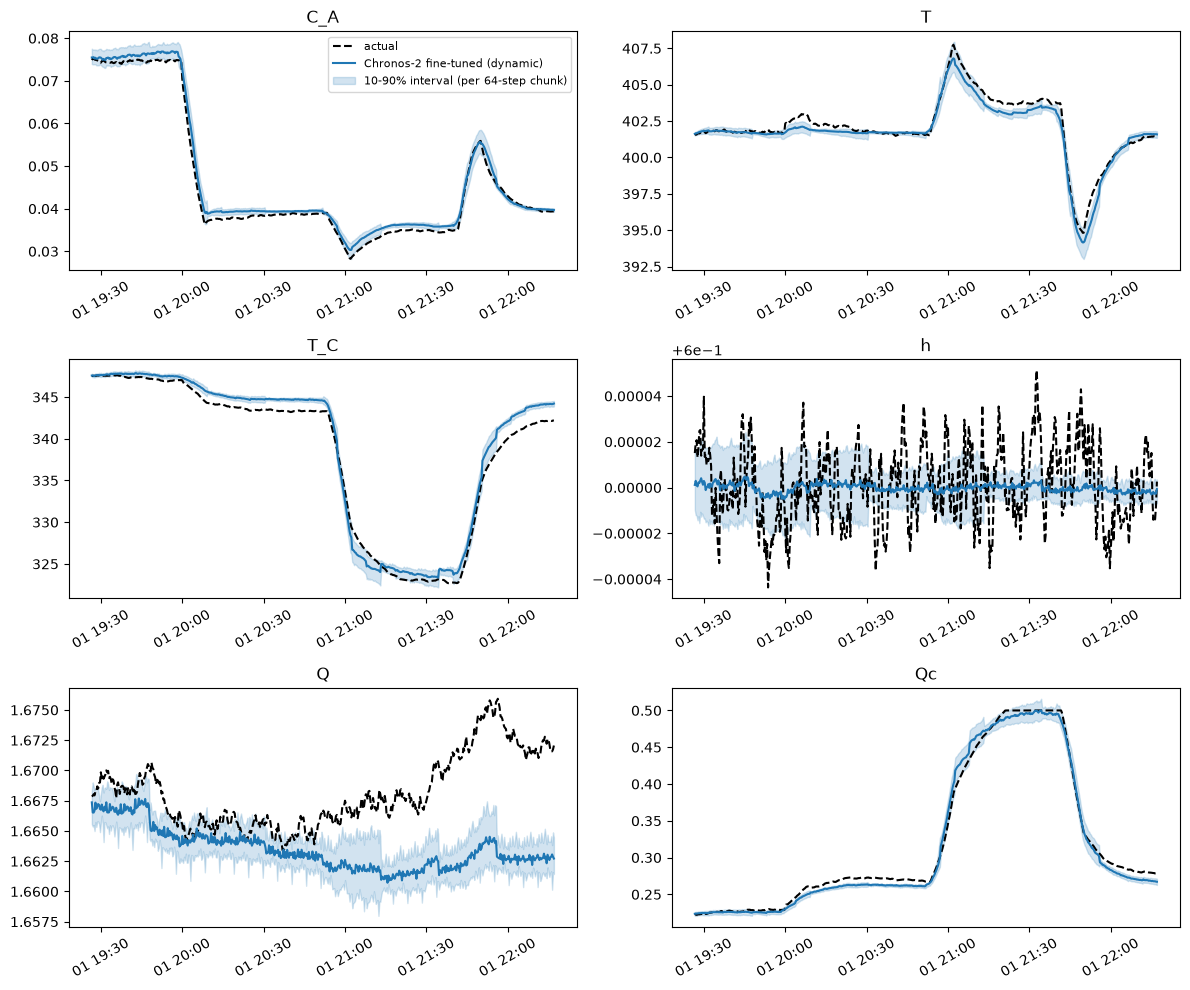

In [16]:
# %% Accuracy vs. the actual simulation, and plots per state
for col in state_cols:
    mae = np.mean(np.abs(sim_df[col].values[:32] - truth_df[col].values[:32]))
    print(f"{col}: MAE = {mae:.5g}")

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for ax, col in zip(axes.ravel(), state_cols):
    ax.plot(truth_df["timestamp"], truth_df[col], color="black", linestyle="--", label="actual")
    ax.plot(sim_df["timestamp"], sim_df[col], color="tab:blue", label=f"{MODEL_LABEL} (dynamic)")
    ax.fill_between(sim_df["timestamp"], sim_df[f"{col}_0.1"], sim_df[f"{col}_0.9"], color="tab:blue", alpha=0.2, label=f"10-90% interval (per {PREDICTION_LENGTH}-step chunk)")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
axes.ravel()[0].legend(fontsize=8)
fig.tight_layout()